In [ ]:
!pip install ultralytics opencv-python easyocr numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 22.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving numberplate.jpg to numberplate (2).jpg


In [ ]:
import os
print(os.listdir())

['.config', 'numberplate (2).jpg', 'Number_plate_detection.ipynb', 'numberplate.jpg', 'license_plate_detector.pt', 'numberplate (1).jpg', 'sample_data']


In [ ]:
!wget https://github.com/Muhammad-Zeerak-Khan/Automatic-License-Plate-Recognition-using-YOLOv8/raw/main/license_plate_detector.pt


--2026-04-27 17:34:01--  https://github.com/Muhammad-Zeerak-Khan/Automatic-License-Plate-Recognition-using-YOLOv8/raw/main/license_plate_detector.pt
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Muhammad-Zeerak-Khan/Automatic-License-Plate-Recognition-using-YOLOv8/main/license_plate_detector.pt [following]
--2026-04-27 17:34:02--  https://raw.githubusercontent.com/Muhammad-Zeerak-Khan/Automatic-License-Plate-Recognition-using-YOLOv8/main/license_plate_detector.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6241454 (6.0M) [application/octet-stream]
Saving to: ‘license_plate_detector.pt.1’



In [ ]:
import cv2
import torch
import re
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr

In [ ]:
img = cv2.imread('numberplate.jpg')  # replace with your file name


Image path: numberplate (2).jpg


(np.float64(-0.5), np.float64(1399.5), np.float64(971.5), np.float64(-0.5))

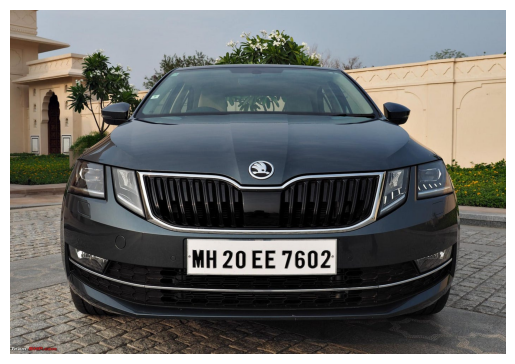

In [ ]:
IMAGE_PATH = list(uploaded.keys())[0]
print("Image path:", IMAGE_PATH)

img = cv2.imread(IMAGE_PATH)

if img is None:
    raise ValueError(f"Image not loaded: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

import matplotlib.pyplot as plt
plt.imshow(img_rgb)
plt.axis("off")


In [ ]:
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8n-license-plate.pt


In [ ]:
model = YOLO("license_plate_detector.pt")


In [ ]:
results = model(img)

plates = []
for r in results:
    if r.boxes is not None:
        for box in r.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            crop = img[y1:y2, x1:x2]
            plates.append(crop)

print(f"Plates detected: {len(plates)}")



0: 448x640 1 license_plate, 182.6ms
Speed: 5.5ms preprocess, 182.6ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Plates detected: 1


In [ ]:
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())


In [ ]:
def clean_plate_text(text):
    text = text.upper()
    text = re.sub(r'[^A-Z0-9]', '', text)
    return text


def smart_digit_correction(plate):
    # Fix 8 → 6 in district code
    chars = list(plate)
    if len(chars) >= 4:
        if chars[2] == '8':
            chars[2] = '6'
        if chars[3] == '8':
            chars[3] = '6'
    return "".join(chars)


def fix_missing_series_letter(cleaned_text, raw_ocr_texts):
    """
    Fix KL653121 → KL65L3121
    """
    if len(cleaned_text) == 9:
        return cleaned_text

    if len(cleaned_text) == 8:
        state = cleaned_text[:2]
        district = cleaned_text[2:4]
        number = cleaned_text[4:]

        # Try to recover letter from OCR fragments
        series_letter = None
        for t in raw_ocr_texts:
            t = t.strip().upper()
            if len(t) == 1 and t.isalpha():
                series_letter = t
                break

        if series_letter is None:
            series_letter = "X"

        return state + district + "L" + number

    return cleaned_text




In [ ]:
final_plate = None

if plates:
    for plate in plates:
        gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
        ocr = reader.readtext(gray)

        raw_texts = [t for (_, t, _) in ocr]
        combined = " ".join(raw_texts)

        cleaned = clean_plate_text(combined)
        corrected = smart_digit_correction(cleaned)
        final_plate = fix_missing_series_letter(corrected, raw_texts)

        break



In [ ]:
if final_plate is None:
    print("No plate detected — using OCR fallback")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ocr = reader.readtext(gray)

    raw_texts = [text for (_, text, _) in ocr]
    print("Raw OCR Text:", raw_texts)

    combined = " ".join(raw_texts)
    print("Combined OCR:", combined)

    cleaned = clean_plate_text(combined)
    print("Cleaned OCR:", cleaned)

    corrected = smart_digit_correction(cleaned)
    print("Digit-corrected:", corrected)

    final_plate = fix_missing_series_letter(corrected, raw_texts)


In [ ]:
if final_plate:
    print("FINAL LICENSE PLATE:", final_plate)
else:
    print("License plate not detected")



FINAL LICENSE PLATE: MH20EE7602
